
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Application de l'algorithme kNN sur des données Cancer.
</p>

---



Sous-sections :
[Initialisation](#init)&nbsp;|
[Les données](#donnees)&nbsp;|
[La base de cas](#cb)&nbsp;|
[La mesure de similarité](#similarite)&nbsp;|
[La prédiction avec kNN](#knn)&nbsp;|



On travaille ici sur un jeu de données de $1097$ images de radiographie des poumons :
https://www.kaggle.com/datasets/leelanaveenkumar/lung-cancer-ct-slice-images-metadatasynthetic

Chaque image est accompagnée d'un label :
- $536$ images ont le label $0$ (normal, pas de cancer sur l'image)
- $561$ images ont le label $1$ (cancereux, présence d'un cancer sur l'image)

L'objectif sera d'utiliser l'algorithme des $k$ plus proches voisins pour prédire pour une nouvelle image a présence ou non d'un cancer sur l'image.

<a id="init"></a>
### Initialisation

In [1]:
import sys, os
try:
    CURRENT_FOLDER = os.path.dirname(__file__) # normal way
except NameError:
    CURRENT_FOLDER = globals()['_dh'][0] # jupyter notebook way

sys.path.append(str(CURRENT_FOLDER / "../")) # ou sys.path.append(os.path.join(CURRENT_FOLDER, "../"))

DATA_FOLDER = CURRENT_FOLDER / '../../data/lung-cancer-smoking-dataset'
IMAGES_DIR = DATA_FOLDER / 'Images'
METADATA_CSV_FILE = DATA_FOLDER / 'metadata/metadata.csv'

In [2]:
sys.path

['/home/fadi/e/opt/miniconda3/envs/l3sv/lib/python310.zip',
 '/home/fadi/e/opt/miniconda3/envs/l3sv/lib/python3.10',
 '/home/fadi/e/opt/miniconda3/envs/l3sv/lib/python3.10/lib-dynload',
 '',
 '/home/fadi/e/opt/miniconda3/envs/l3sv/lib/python3.10/site-packages',
 '/home/fadi/e/src/python/m1/2025_2026/tps/seance_4_resolution_des_noms/lung_cancer/..']

<a id="donnees"></a>
### Les données

In [3]:
import pandas as pd
df = pd.read_csv(METADATA_CSV_FILE)
df

,patient_id,age,gender,smoking_status,cancer_diagnosis
0,Patient (1),80,Male,Never Smoked,0
1,Patient (2),57,Male,Never Smoked,0
2,Patient (3),46,Male,Never Smoked,0
3,Patient (4),42,Male,Never Smoked,0
4,Patient (5),54,Male,Never Smoked,0
...,...,...,...,...,...
1092,Patient (1093),79,Male,Current Smoker,1
1093,Patient (1094),61,Male,Current Smoker,1
1094,Patient (1095),60,Male,Never Smoked,1
1095,Patient (1096),77,Male,Current Smoker,1


In [4]:
import numpy as np
data = np.load(DATA_FOLDER / 'lung_cancer.npz')
all_images = data['images']
all_labels = data['labels']

In [ ]:
N = 200 # on prend seulement les 200 premières images (sinon kNN prend 3mn...)
indices = np.random.randint(len(all_images),size=N)
images = all_images[indices]
labels = all_labels[indices]

### Afficher les images

Voici une fonction qui permet d'afficher une liste d'images à partir de leurs indices.

In [ ]:
import matplotlib.pyplot as plt
def afficher_images(*indices):
    n = len(indices)
    if n == 1:
        plt.imshow(images[indices[0]]), labels[indices[0]]
    else:
        fig, axes = plt.subplots(nrows=1, ncols=n,figsize=(2*n, n), dpi=100)
        for i,idx in enumerate(indices):
            axes[i].imshow(images[idx])
            axes[i].set_title(f'Image {idx} Label {labels[idx]}')

3


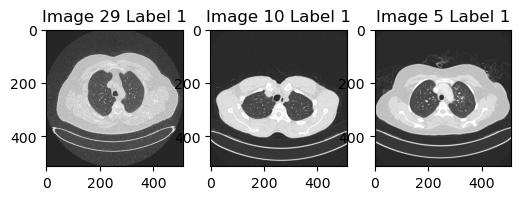

In [16]:
afficher_images(29,10,5)

<a id="cible"></a>
### Le cas cible

Le cas cible dont on veut prédire le label est l'image d'indice `cible_idx`.

In [ ]:
cible_idx = 154
afficher_images(cible_idx)

Pour pouvoir calculer les similarités, on écrit une fonction `vect` qui transforme les images en vecteurs de nombres.

In [9]:
def vect(array):
    """ Transforms an image into a Python list.  """
    return array.flatten().tolist()

x, y_true = vect(images[cible_idx]), vect(labels[cible_idx])


<a id="cb"></a>
### La base de cas

Pour prédire le label de l'image numéro `cible_idx`, on prend comme base de cas l'ensemble des autres images :

In [10]:
def cb(i):
    """ Cette fonction renvoie tous les cas sauf le cas numéro i, 
    sous forme de deux vecteurs X_cb et y_cb.  """
    return (list(vect(image) for image in np.delete(images, i, axis=0)), vect(np.delete(labels,i)))

X_cb, y_cb = cb(cible_idx)

<a id="similarite"></a>
### La mesure de similarité

On utilise la mesure de similarité cosinus, implémentée dans la fonction `cosin` du module `measures`.  

In [ ]:
from cbp.similarity.measures import cosin

i = 0
cosin(X_cb[i],x)

<a id="knn"></a>
### La prédiction avec kNN

Utiliser l'algorithme des $k$ plus proches voisins pour prédire la présence ou non de cancer sur l'image numéro `cible_idx`.
 

In [ ]:
# <- completer ici


1

Afficher l'image uméro `cible_idx` ainsi que les $k$ images les plus similaires à cette image.

In [ ]:
# <- completer ici
